---

## Module 11 — Chatbot UI with Streamlit (Part 1 of 2)

Adding a proper web interface to the LangGraph chatbot — splitting it into a **backend** (LangGraph) and a **frontend** (Streamlit).

---

### 🏗️ Architecture
```
User types message
      ↓
[Streamlit Frontend]  ←→  [LangGraph Backend]
  frontend.py               langgraph_backend.py
```

The frontend handles display and user input. The backend handles LLM logic and memory. They live in two separate `.py` files in the same project folder.

> 📌 *This is the same chatbot code from Module 09 — just reorganized. The LangGraph workflow becomes the backend; the `while` loop that handled user input becomes the Streamlit frontend.*

---

### 📁 Project Structure
```
chatbot_ui/
├── langgraph_backend.py   ← LangGraph workflow (this file)
├── streamlit_frontend.py  ← Streamlit UI (next section)
└── .env                   ← OPENAI_API_KEY
```

---

### 🔧 `langgraph_backend.py`

In [2]:
%%writefile langgraph_backend.py

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import BaseMessage
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
import os

load_dotenv(override=True)

llm = ChatOpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    model="gpt-4o-mini"
)

class ChatState(TypedDict):
    # full conversation history — add_messages appends instead of replacing
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    """Pass full conversation history to LLM and return its reply."""
    response = llm.invoke(state['messages'])  # response is already an AIMessage
    return {"messages": [response]}

checkpointer = InMemorySaver()

graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

# export this — the frontend will import and call it
chatbot = graph.compile(checkpointer=checkpointer)

Overwriting langgraph_backend.py


> 📌 *`load_dotenv(override=True)` forces the `.env` file to take priority over any existing environment variables — useful when running outside Jupyter where env vars might already be set.*

> 📌 *`chatbot` is exported at module level so the Streamlit frontend can simply `from langgraph_backend import chatbot` and invoke it directly.*

---

> ⏭️ *Next — building the Streamlit frontend!* 🔥

---

### 🖥️ `streamlit_frontend.py`

In [3]:
%%writefile streamlit_frontend.py

import streamlit as st
from langgraph_backend import chatbot
from langchain_core.messages import HumanMessage

# thread_id ties all messages to one conversation session
CONFIG = {'configurable': {'thread_id': 'thread-1'}}

# session_state persists across Streamlit reruns — stores display history
if 'message_history' not in st.session_state:
    st.session_state['message_history'] = []

# render all previous messages on every rerun
for message in st.session_state['message_history']:
    with st.chat_message(message['role']):       # 'user' or 'assistant'
        st.markdown(message['content'])

# renders the input box at the bottom — returns None until user submits
user_input = st.chat_input("Ask me anything...")

if user_input:
    # display and store the user message
    st.session_state['message_history'].append({'role': 'user', 'content': user_input})
    with st.chat_message('user'):
        st.markdown(user_input)

    # send to LangGraph — only the new message; checkpointer handles the rest
    response = chatbot.invoke(
        {'messages': [HumanMessage(content=user_input)]},
        config=CONFIG
    )

    # extract the text content from the LangGraph response
    last_msg = response['messages'][-1]
    ai_message = last_msg.content if hasattr(last_msg, 'content') else str(last_msg)

    # display and store the AI reply
    st.session_state['message_history'].append({'role': 'assistant', 'content': ai_message})
    with st.chat_message('assistant'):
        st.markdown(ai_message)

Writing streamlit_frontend.py


---

#### Run the app

In [6]:
!streamlit run streamlit_frontend.py

^C


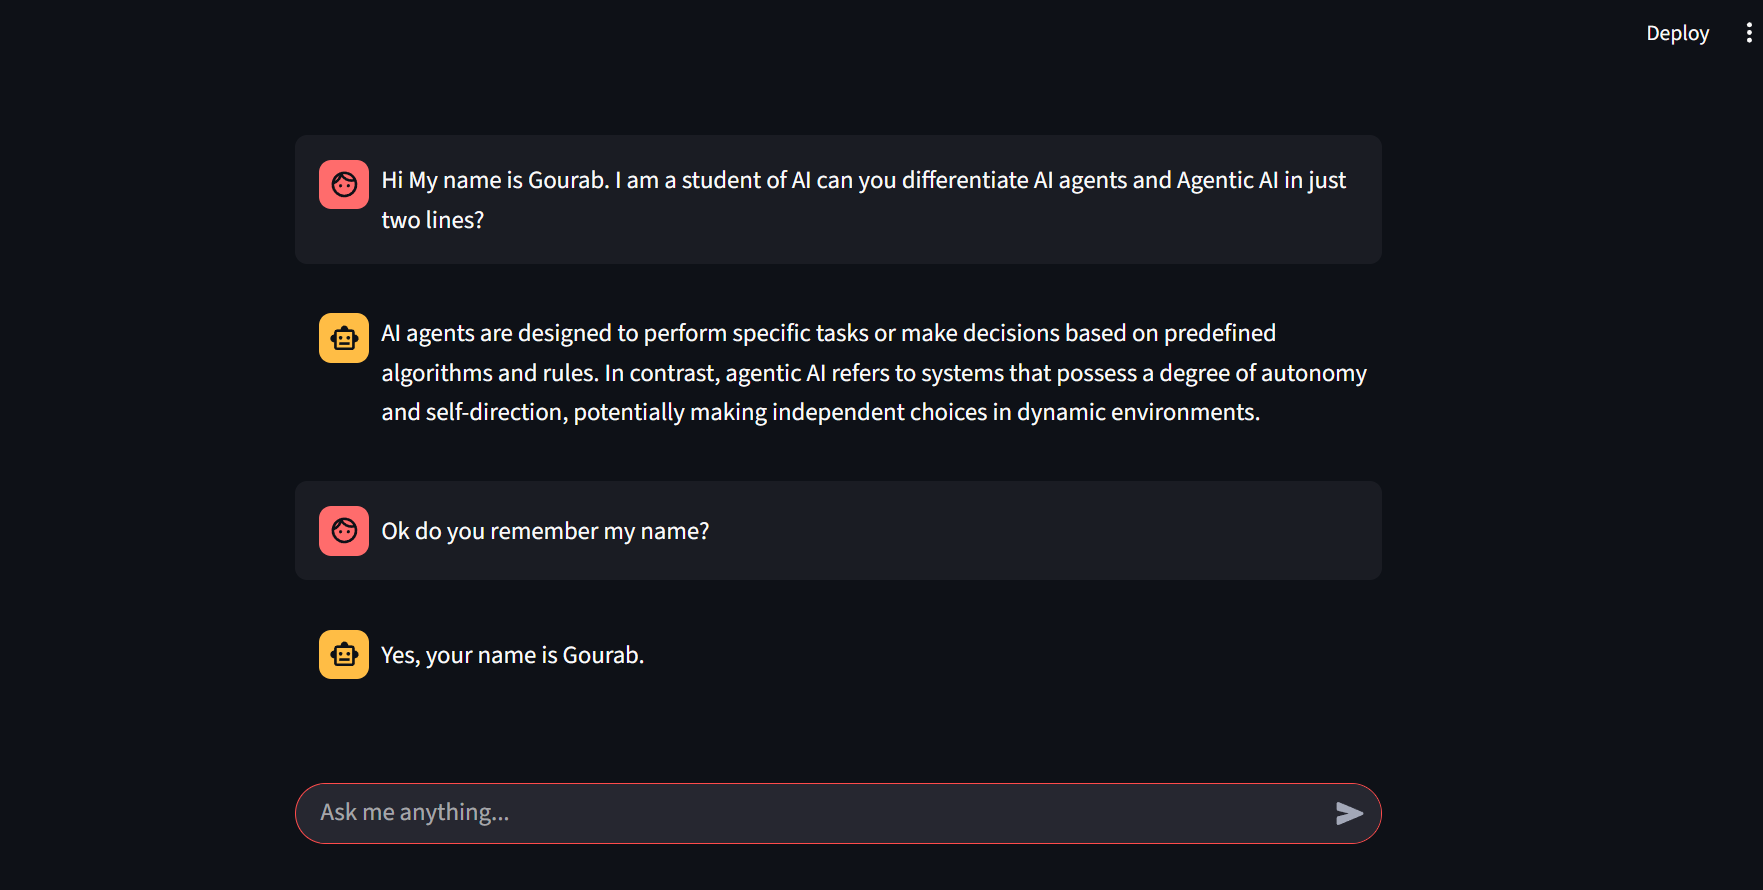

---

### 🔑 Two Separate Memory Systems

This app uses **two independent memory systems** — understanding both is important:

| Memory | What it stores | Lives where | Survives page refresh? |
|---|---|---|---|
| `st.session_state` | Messages for display (role + content strings) | Browser session | ❌ No |
| `InMemorySaver` (checkpointer) | LangChain `BaseMessage` objects for LLM context | RAM | ❌ No |

> 📌 *`st.session_state` is Streamlit's way of persisting Python variables across reruns — every user interaction triggers a full script rerun, so without `session_state` the message history would reset on every message.*

> 📌 *The checkpointer and `session_state` are kept in sync but serve different purposes — `session_state` drives what the UI renders, the checkpointer drives what the LLM receives as context. They must both be maintained separately.*

---

#### Why only the new message is passed to `chatbot.invoke()`

```python
# only the latest HumanMessage is passed here
chatbot.invoke({'messages': [HumanMessage(content=user_input)]}, config=CONFIG)

# the checkpointer automatically restores the full history for thread-1
# add_messages reducer appends the new message to the restored history
# LLM receives the complete conversation — not just the latest message
```

> 📌 *This is the same pattern from Module 09 — passing `None` or just the new message works because the checkpointer rehydrates the full state before `add_messages` appends. The LLM always sees everything.*

---

#### How Streamlit reruns work
```
User types message → Streamlit reruns entire script from top
                   → session_state still has old messages → renders them
                   → user_input has new value → enters if block
                   → invokes chatbot → gets response → appends both → renders both
```

> 📌 *The full message loop at the top rerenders all previous messages on every rerun — this is intentional in Streamlit. Without it, old messages would disappear each time.*